# 04 Survival

Flood-It! retention and churn project. Run cells top to bottom.

### Imports and settings

In [1]:
import pandas as pd                                                    # tables
import numpy as np                                                     # maths
import matplotlib.pyplot as plt                                        # charts
from lifelines import KaplanMeierFitter, CoxPHFitter                   # survival analysis models
from lifelines.statistics import logrank_test, multivariate_logrank_test   # tests that compare survival curves
from pathlib import Path                                               # file paths

pd.set_option("display.max_columns", None)                             # never hide columns
pd.set_option("display.width", 200)                                    # wide printing

### Paths, data and survival columns

In [2]:
ROOT = Path.cwd()                                                      # folder the notebook runs in
if ROOT.name == "notebooks":                                           # if inside notebooks/...
    ROOT = ROOT.parent                                                 # ...go up to the project root
DATA = ROOT / "data" / "processed"                                     # data folder
FIG = ROOT / "reports" / "figures"                                     # charts folder
players = pd.read_csv(DATA / "player_features.csv")                    # one row per new player
players["duration_days"] = players["last_active_day_number"] + 1       # days from joining to last seen (joining day counts as 1)
players["churn_observed"] = ((players["days_observable"] - players["last_active_day_number"]) >= 7).astype(int)   # 1 = silent for 7+ days before data ended
print(players[["duration_days", "churn_observed"]].describe().round(2))  # quick summary
print("Share with churn observed:", round(players["churn_observed"].mean(), 4), "| censored (still possibly active):", round(1 - players["churn_observed"].mean(), 4))

       duration_days  churn_observed
count       11066.00         11066.0
mean           16.31             0.9
std            27.22             0.3
min             1.00             0.0
25%             1.00             1.0
50%             1.00             1.0
75%            19.00             1.0
max           107.00             1.0
Share with churn observed: 0.9035 | censored (still possibly active): 0.0965


### Kaplan-Meier curve for all new players

Median days until churn: 1.0
Probability still active after day 1: 0.457
Probability still active after day 2: 0.421
Probability still active after day 3: 0.398
Probability still active after day 7: 0.340
Probability still active after day 14: 0.291
Probability still active after day 30: 0.212


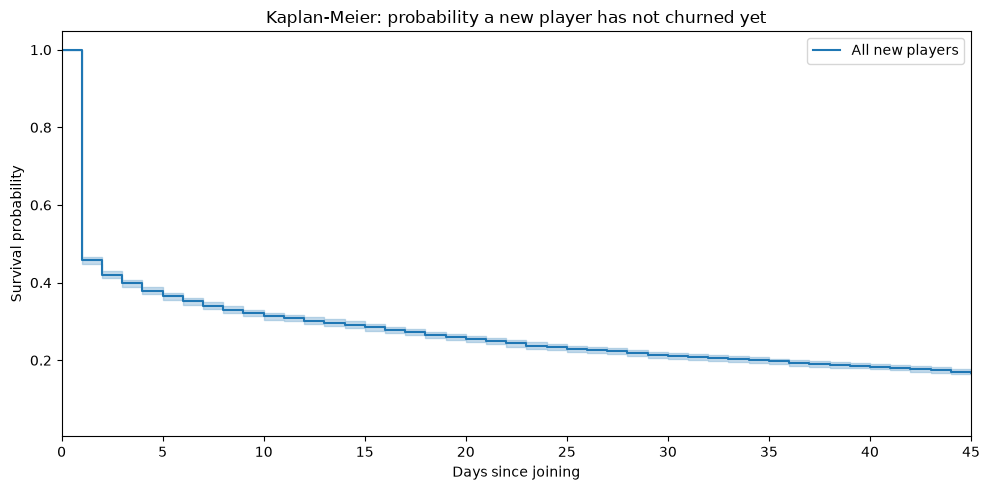

In [3]:
kmf = KaplanMeierFitter()                                              # create the estimator
kmf.fit(players["duration_days"], event_observed=players["churn_observed"], label="All new players")   # fit on everyone
print("Median days until churn:", kmf.median_survival_time_)           # half of players have churned by this day
for day in [1, 2, 3, 7, 14, 30]:                                       # read the curve at a few points
    print(f"Probability still active after day {day}: {kmf.predict(day):.3f}")   # survival probability
fig, ax = plt.subplots(figsize=(10, 5))                                # empty chart
kmf.plot_survival_function(ax=ax)                                      # curve with a confidence band
ax.set_title("Kaplan-Meier: probability a new player has not churned yet")   # title
ax.set_xlabel("Days since joining")                                    # x label
ax.set_ylabel("Survival probability")                                  # y label
ax.set_xlim(0, 45)                                                     # focus on the first 45 days
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "10_km_overall.png", dpi=150)                        # save
plt.show()                                                             # display

### Compare platforms with a log-rank test

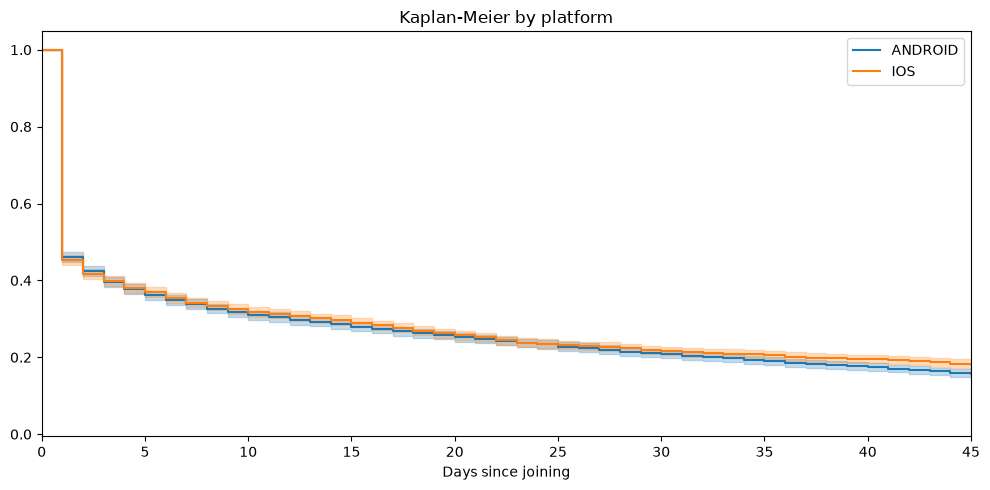

Log-rank test iOS vs Android: statistic = 14.75, p = 0.0001227


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))                                # empty chart
for platform in sorted(players["platform"].unique()):                  # one loop, one curve per platform
    group = players[players["platform"] == platform]                   # rows for this platform
    KaplanMeierFitter().fit(group["duration_days"], group["churn_observed"], label=platform).plot_survival_function(ax=ax)   # fit and draw
ax.set_xlim(0, 45)                                                     # first 45 days
ax.set_title("Kaplan-Meier by platform")                               # title
ax.set_xlabel("Days since joining")                                    # x label
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "11_km_platform.png", dpi=150)                       # save
plt.show()                                                             # display
if players["platform"].nunique() == 2:                                 # log-rank needs exactly two groups
    g1 = players[players["platform"] == "IOS"]                         # iOS players
    g2 = players[players["platform"] == "ANDROID"]                     # Android players
    result = logrank_test(g1["duration_days"], g2["duration_days"], g1["churn_observed"], g2["churn_observed"])   # compare whole curves
    print(f"Log-rank test iOS vs Android: statistic = {result.test_statistic:.2f}, p = {result.p_value:.4g}")

### Compare day-0 milestones (more than two groups)

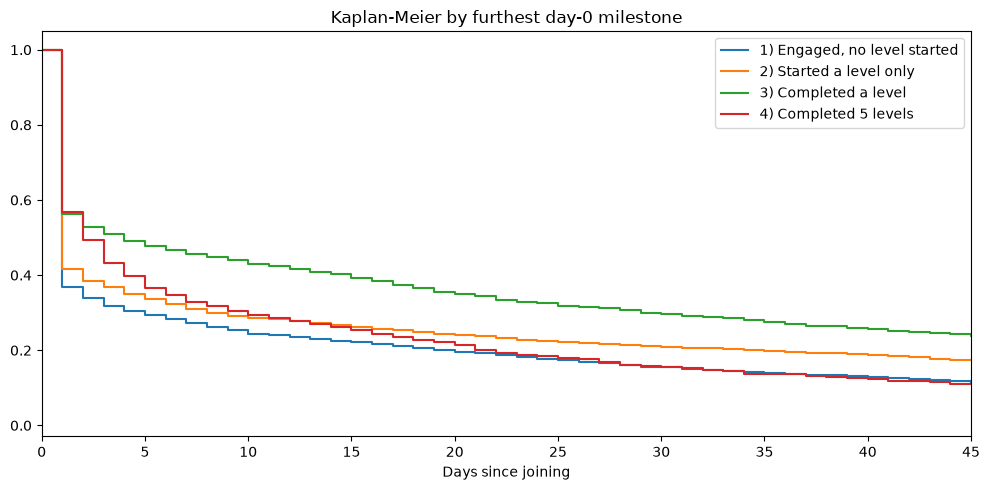

Multivariate log-rank: statistic = 268.0, p = 8.4e-58


In [5]:
players["milestone"] = np.select(
    [players["d0_completed_5_levels"] > 0, players["d0_levels_completed"] > 0, players["d0_levels_started"] > 0],   # conditions in priority order
    ["4) Completed 5 levels", "3) Completed a level", "2) Started a level only"],                                  # matching labels
    default="1) Engaged, no level started")                             # everything else
fig, ax = plt.subplots(figsize=(10, 5))                                # empty chart
for milestone in sorted(players["milestone"].unique()):                # one loop, one curve per milestone
    group = players[players["milestone"] == milestone]                 # rows for this group
    KaplanMeierFitter().fit(group["duration_days"], group["churn_observed"], label=milestone).plot_survival_function(ax=ax, ci_show=False)   # curve without band
ax.set_xlim(0, 45)                                                     # first 45 days
ax.set_title("Kaplan-Meier by furthest day-0 milestone")               # title
ax.set_xlabel("Days since joining")                                    # x label
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "12_km_milestone.png", dpi=150)                      # save
plt.show()                                                             # display
multi = multivariate_logrank_test(players["duration_days"], players["milestone"], players["churn_observed"])   # all groups at once
print(f"Multivariate log-rank: statistic = {multi.test_statistic:.1f}, p = {multi.p_value:.3g}")

### Cox proportional hazards model

In [6]:
cox_df = pd.DataFrame({
    "duration_days": players["duration_days"],                         # time
    "churn_observed": players["churn_observed"],                       # event flag
    "log_engaged_minutes": np.log1p(players["d0_engaged_minutes"]),    # log scale tames skew
    "log_levels_completed": np.log1p(players["d0_levels_completed"]),  # log scale
    "d0_sessions": players["d0_sessions"],                             # sessions on day 0
    "is_ios": (players["platform"] == "IOS").astype(int),              # 1 = iOS
})
cph = CoxPHFitter(penalizer=0.01)                                      # small penalty keeps estimates stable
cph.fit(cox_df, duration_col="duration_days", event_col="churn_observed")   # fit the model
hazards = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].round(4)   # hazard ratios with CIs
print(hazards)                                                         # below 1 = lower churn risk, above 1 = higher
print("Concordance index:", round(cph.concordance_index_, 3))          # 0.5 = random ordering, 1 = perfect ordering

                      exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%       p
covariate                                                                        
log_engaged_minutes      0.9161               0.8955               0.9371  0.0000
log_levels_completed     0.8486               0.8173               0.8810  0.0000
d0_sessions              0.9281               0.8965               0.9609  0.0000
is_ios                   0.9811               0.9433               1.0205  0.3426
Concordance index: 0.594


### Check the proportional hazards assumption

In [7]:
ph_test = cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=False)   # prints advice if a variable violates the assumption

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'log_engaged_minutes' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'log_engaged_minutes' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'log_engaged_minutes' using pd.cut, and then specify it in
`strata=['log_engaged_minutes', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'log_levels_completed' failed the non-proportional test: p-value is 0.0001.

   Advice 1: the functional form of the variable 'log_levels_completed' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms